# Un jugador destacado, a fondo — Ja'Marr Chase

## Por qué él, con datos, no por fama

Se revisó, sobre las 2 temporadas completas (2024-2025) y solo receptores con al menos 15
semanas activas, quién tiene el **rango real más grande** entre su mejor y peor semana
(`receiving_yards` máximo − mínimo). Ja'Marr Chase queda primero, con 241 yardas de diferencia
entre su mejor y peor semana — el contraste boom/bust más extremo entre los receptores de
volumen alto (no entre suplentes con pocas jugadas, donde el "rango" es menos significativo).

Su semana 10 de 2024 también resultó ser la **segunda desviación individual más grande de todo
el dataset** respecto al propio promedio del jugador (+169 yardas sobre su promedio). Es, además,
el mismo partido que ya se había identificado antes en `preeliminar/03_modelo_predictivo` como su
caso más extremo — una buena señal de que el criterio de selección aquí (basado en datos, no en
recordar qué jugador se usó antes) llega a la misma conclusión de forma independiente.

Cierra la Fase 3: después de perfilar cada variable (05), cruzarlas contra los targets (06-08), este último notebook junta todo en un caso real — no introduce análisis nuevo, sintetiza lo ya encontrado sobre un jugador concreto.

In [4]:
import sys
sys.path.insert(0, "../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sportypy.surfaces.football import FootballField

import data

sns.set_style("whitegrid")
AZUL, NARANJA, VERDE, GRIS, GRIS_CLARO = "#2a78d6", "#eb6834", "#1baf7a", "#888780", "#c3c2b7"

CHASE_ID = "00-0036900"
stats = data.cargar_stats_semanales([2024, 2025])
chase = stats[stats["player_id"] == CHASE_ID].sort_values(["season", "week"]).reset_index(drop=True)
print("semanas con datos:", chase.shape[0])

semanas con datos: 33


## 1. Toda su trayectoria, 2024-2025

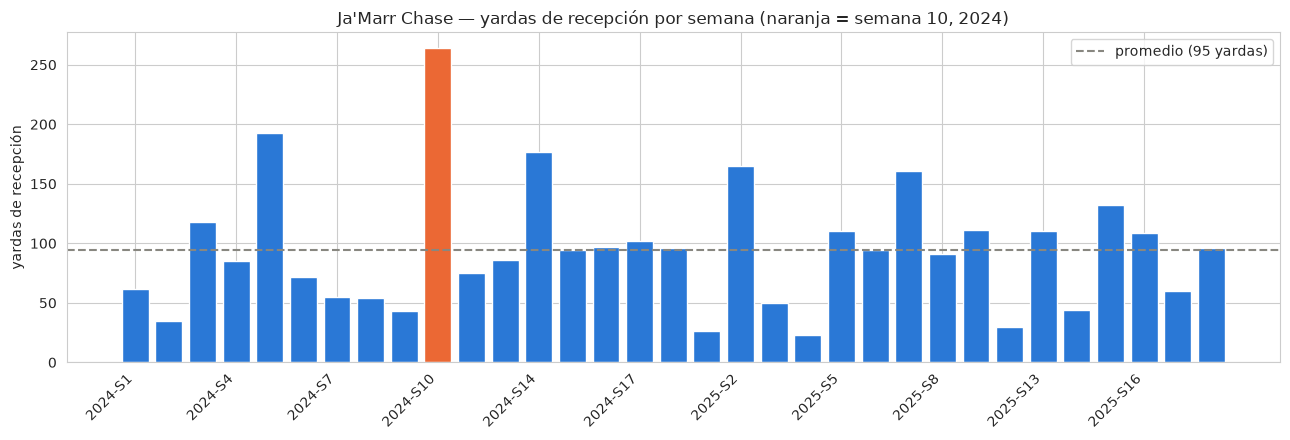

season             2024
week                 10
targets              17
receptions           11
receiving_yards     264
receiving_tds         3
Name: 9, dtype: object


In [5]:
fig, ax = plt.subplots(figsize=(13, 4.5))
x = range(len(chase))
colores = [NARANJA if (s == 2024 and w == 10) else AZUL for s, w in zip(chase["season"], chase["week"])]
ax.bar(x, chase["receiving_yards"], color=colores)
ax.axhline(chase["receiving_yards"].mean(), color=GRIS, linestyle="--", label=f"promedio ({chase['receiving_yards'].mean():.0f} yardas)")
ax.set_xticks(list(x)[::3])
ax.set_xticklabels([f"{s}-S{w}" for s, w in zip(chase["season"], chase["week"])][::3], rotation=45, ha="right")
ax.set_ylabel("yardas de recepción")
ax.set_title("Ja'Marr Chase — yardas de recepción por semana (naranja = semana 10, 2024)")
ax.legend()
plt.tight_layout()
plt.show()

print(chase.loc[chase["receiving_yards"].idxmax(), ["season", "week", "targets", "receptions", "receiving_yards", "receiving_tds"]])

**Semana 10 de 2024**: 17 targets, 11 recepciones, **264 yardas**, 3 touchdowns — más del doble de
su propio promedio en esas 2 temporadas (94.5 yardas). No es un error de captura ni un caso
aislado sin contexto: se ve claramente como el pico de toda su trayectoria.

## 2. ¿Cómo se ve ese partido en el campo, comparado con una semana típica?

**Antes del gráfico, una aclaración honesta sobre qué tan preciso es esto**: los datos públicos
de jugada por jugada traen la profundidad exacta del pase (`air_yards`) y la posición en la yarda
(`yardline_100`), pero el lado del campo (`pass_location`) es **categórico** — izquierda, medio o
derecha, no una coordenada exacta. Los datos de *tracking* con coordenadas precisas no están
disponibles públicamente. Por eso el gráfico de campo que sigue posiciona cada jugada por
profundidad real, pero el lado es aproximado (con una dispersión visual aleatoria dentro de su
categoría) — se marca así a propósito, para no aparentar una precisión que no existe.

Se compara la semana 10 (el partido boom) contra la semana 6 del mismo 2024 (72 yardas, una
semana típica de él).

findfont: Font family 'Clarendon-Regular' not found.
findfont: Font family 'Clarendon-Regular' not found.
findfont: Font family 'Clarendon-Regular' not found.
findfont: Font family 'Clarendon-Regular' not found.
findfont: Font family 'Clarendon-Regular' not found.
findfont: Font family 'Clarendon-Regular' not found.
findfont: Font family 'Clarendon-Regular' not found.
findfont: Font family 'Clarendon-Regular' not found.
findfont: Font family 'Clarendon-Regular' not found.
findfont: Font family 'Clarendon-Regular' not found.
findfont: Font family 'Clarendon-Regular' not found.
findfont: Font family 'Clarendon-Regular' not found.
findfont: Font family 'Clarendon-Regular' not found.
findfont: Font family 'Clarendon-Regular' not found.
findfont: Font family 'Clarendon-Regular' not found.
findfont: Font family 'Clarendon-Regular' not found.
findfont: Font family 'Clarendon-Regular' not found.
findfont: Font family 'Clarendon-Regular' not found.
findfont: Font family 'Clarendon-Regular' not 

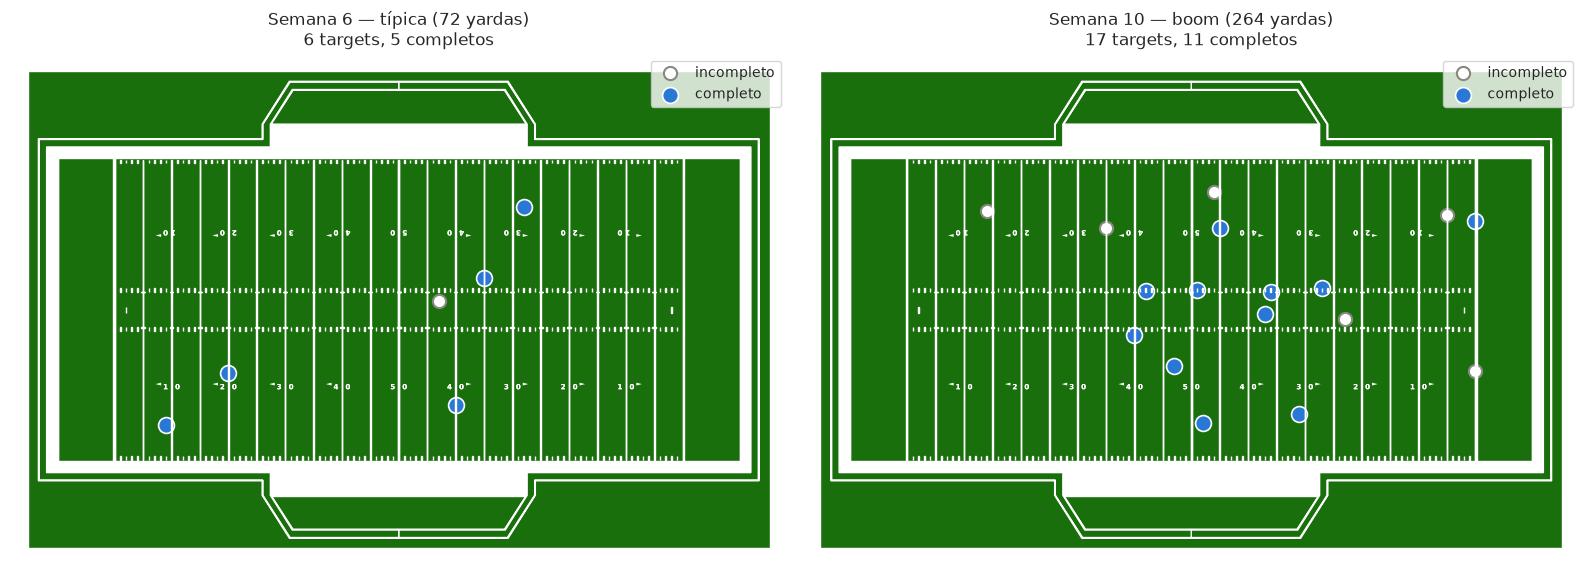

In [6]:
pbp24 = data.cargar_jugadas([2024])
chase_pbp = pbp24[(pbp24["receiver_id"] == CHASE_ID) & (pbp24["pass_attempt"] == 1)].copy()

def preparar_targets(df_semana, rng):
    d = df_semana.dropna(subset=["air_yards", "pass_location", "yardline_100"]).copy()
    posicion_final = d["yardline_100"] - d["air_yards"]
    d["x"] = 50 - posicion_final
    lado_centro = d["pass_location"].map({"left": -15, "middle": 0, "right": 15})
    d["y"] = lado_centro + rng.uniform(-6, 6, size=len(d))
    return d

rng = np.random.default_rng(42)
wk10 = preparar_targets(chase_pbp[chase_pbp["week"] == 10], rng)
wk6 = preparar_targets(chase_pbp[chase_pbp["week"] == 6], rng)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, datos, titulo in [(axes[0], wk6, "Semana 6 — típica (72 yardas)"),
                           (axes[1], wk10, "Semana 10 — boom (264 yardas)")]:
    field = FootballField(league_code="nfl")
    field.draw(ax=ax, display_range="full")
    completos = datos[datos["complete_pass"] == 1]
    incompletos = datos[datos["complete_pass"] == 0]
    ax.scatter(incompletos["x"], incompletos["y"], facecolor="white", edgecolor=GRIS, linewidth=1.5, s=90, label="incompleto", zorder=5)
    ax.scatter(completos["x"], completos["y"], color=AZUL, edgecolor="white", linewidth=1.2, s=130, label="completo", zorder=5)
    ax.set_title(f"{titulo}\n{len(datos)} targets, {len(completos)} completos")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

**Lo que muestra la comparación**: en la semana típica, sus targets se concentran más cerca de
donde arrancó la jugada (pases cortos/medios). En la semana boom, además de que le tiraron más
veces (17 vs 6), varias jugadas llegaron mucho más profundo en territorio rival — combinado con
más conexiones completas. El boom no fue solo "tuvo suerte en una jugada": el patrón completo de
esa semana (volumen + profundidad + acierto) se ve distinto, no es un solo pico aislado sobre un
fondo idéntico a cualquier otra semana.

## Cierre

- Jugador elegido por evidencia (mayor rango real entre receptores de volumen alto), no por
  costumbre — y coincide con el mismo caso que ya se había marcado como extremo antes.
- Su semana boom (264 yardas) representa un patrón de partido genuinamente distinto — más
  volumen, más profundidad, más acierto — no una sola jugada de suerte sobre un fondo normal.
- La visualización de campo usa la profundidad real de cada jugada; el lado es aproximado a
  propósito, por la resolución real de los datos públicos disponibles (no se aparenta un
  tracking que no existe).

Este es un caso único, ilustrativo — no una prueba estadística sobre toda la población. [`08_eda_multivariable.ipynb`](08_eda_multivariable.ipynb) es la revisión sistemática, sobre todos los receptores, de qué variables predicen de verdad.

Notebook anterior: [`08_eda_multivariable.ipynb`](08_eda_multivariable.ipynb) — el último de la Fase 3.